# Bump Chart

A bump chart shows rank over time: one line per series, rank 1 at the top, so the crossings answer *who overtook whom, and when*. It suits league tables, popularity rankings and any table whose order matters more than the gaps between the values. This guide shows how to create bump charts with the [datachart.charts.BumpChart](../../../references/charts/bumpchart/#datachart.charts.BumpChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-bump-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import BumpChart

## Basics

The examples in this guide share one dataset: the populations of ten large countries in 1980, 1990, 2000, 2010, 2020 and 2023, in millions (source: United Nations, World Population Prospects 2022, rounded). The data lives in a hidden cell. `population` holds one series per country, and `COUNTRIES` holds the country names in the same order; the ranks in the charts are ranks among these ten. Population is a ranking story as much as a growth one: India passed China in 2023, Pakistan and Nigeria climbed past Brazil, and Russia and Japan slid down the table.

In [2]:
YEARS = [1980, 1990, 2000, 2010, 2020, 2023]

# population in millions (UN World Population Prospects 2022, rounded)
POPULATION = {
    "China": [982, 1135, 1264, 1348, 1424, 1426],
    "India": [697, 870, 1057, 1234, 1396, 1429],
    "United States": [227, 248, 282, 309, 336, 340],
    "Indonesia": [148, 182, 214, 244, 272, 278],
    "Pakistan": [80, 115, 154, 194, 227, 240],
    "Brazil": [122, 150, 176, 196, 213, 216],
    "Nigeria": [74, 95, 122, 160, 208, 224],
    "Bangladesh": [83, 107, 129, 148, 167, 173],
    "Russia": [139, 148, 146, 143, 145, 144],
    "Japan": [117, 124, 127, 128, 126, 124],
}
COUNTRIES = list(POPULATION)
population = [
    [{"x": year, "y": people} for year, people in zip(YEARS, POPULATION[country])]
    for country in COUNTRIES
]

Each series is a list of `{x, y}` points, with the year as `x` and the population as `y`. These are the values, not the ranks: the chart ranks them at every year. The first two points of the first series:

In [3]:
population[0][:2]

[{'x': 1980, 'y': 982}, {'x': 1990, 'y': 1135}]

**Basic example.** Only the `data` argument is required, and `subtitle` names the lines: each name prints beside the line's last point, in the line's color, so the chart needs no legend and no rank axis. At every year the most populous country takes rank 1 at the top:

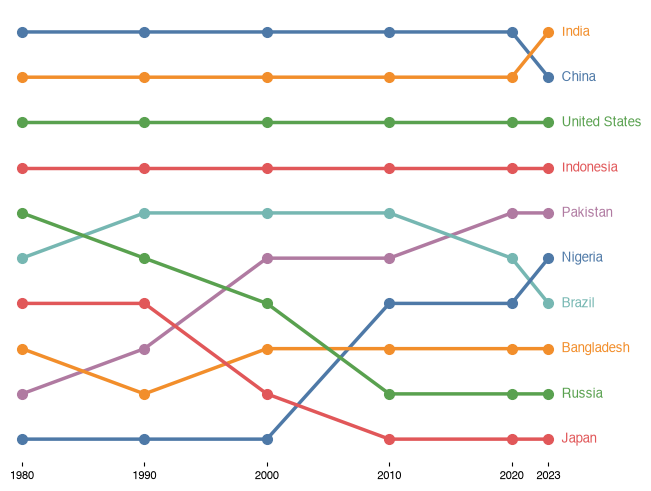

In [4]:
BumpChart(
    # one series per country
    data=population,
    # name the lines at their ends
    subtitle=COUNTRIES,
).show()

## Customizing the Bump Chart

Every customization is either a keyword argument of `BumpChart` or an attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                   | Use                                                                 | See |
| :------------------------------------------- | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                  | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| choose, label, or rotate the period ticks    | `xticks`, `xticklabels`, `xtickrotate`                              | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure or show the grid           | `figsize`, `show_grid`                                              | [Figure size and grid](#figure-size-and-grid) |
| rank the lowest value first                  | `rank_by=BUMP_RANK.VALUE_ASCENDING`                                 | [Ranking](#ranking) |
| draw ranks I already have                    | `rank_by=BUMP_RANK.GIVEN`                                           | [Ranking](#ranking) |
| leave a gap where a series has no rank       | leave the point out of the series                                   | [Ranking](#ranking) |
| name the lines at the start or at both ends  | `show_labels`, `label_position`                                     | [End labels](#end-labels) |
| curve the lines or hide the markers          | `line_curve`, `show_markers`                                        | [Line shape](#line-shape) |
| change the line width, markers, or colors    | `style={"plot_bump_line_width": ..., "plot_line_color": ...}`       | [Line style](#line-style) |
| print the values behind the ranks            | `show_values`, `value_format`, `value_step`                         | [Value labels](#value-labels) |
| highlight some series, mute the rest         | `emphasis`, `emphasis_rule`                                         | [Emphasis](#emphasis) |
| mark a period or shade a range of places     | `vlines`, `hlines`, `dlines`, `vspans`, `hspans`                  | [Reference lines and bands](#reference-lines-and-bands) |
| show every place of the table, or crop it    | `ymin`, `ymax`, `xmin`, `xmax`                                      | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                      | `texts`                                                             | [Text annotations](#text-annotations) |
| use a legend instead of end labels           | `show_labels=False`, `show_legend`, `legend`                        | [Legend](#legend) |
| draw every series in its own subplot         | `subplots`, `sharex`, `sharey`, `max_cols`                          | [Subplots](#subplots) |
| overlay or arrange several bump charts       | `Panel`, `Grid`                                                     | [Composing with Panel and Grid](#composing-with-panel-and-grid) |
| use dates as periods                         | `date` objects as `x`, `xticks_format`                              | [Datetime axis](#datetime-axis) |
| plot data with other key names               | `x`, `y`                                                            | [Custom data keys](#custom-data-keys) |
| change the look of every chart at once       | `config.set_theme`                                                  | [Themes](#themes) |
| save the chart to a file                     | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `rank_by` | [`BUMP_RANK`](../../../references/constants/#datachart.constants.BUMP_RANK) |
| `label_position` | [`BUMP_LABEL_POSITION`](../../../references/constants/#datachart.constants.BUMP_LABEL_POSITION) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `emphasis` | [`EMPHASIS`](../../../references/constants/#datachart.constants.EMPHASIS) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `scalex` | [`SCALE`](../../../references/constants/#datachart.constants.SCALE) |

The full list of style attributes is in the [datachart.typings.BumpStyleAttrs](../../../references/charts/bumpchart/#datachart.typings.BumpStyleAttrs) type; the full list of parameters is in the [datachart.charts.BumpChart](../../../references/charts/bumpchart/#datachart.charts.BumpChart) reference.

### Title, axis labels and ticks

A reader needs to know what is being ranked and by what; `title`, `xlabel` and `ylabel` say it. The period axis gets one tick per period by default. `xticks` picks other positions and `xticklabels` names them, and `xtickrotate` tilts long tick labels out of each other's way. Here the labels spell out that the last step is three years, not ten. `scalex` sets the scale of the period axis with a [SCALE](../../../references/constants/#datachart.constants.SCALE) member, which bump charts rarely need.

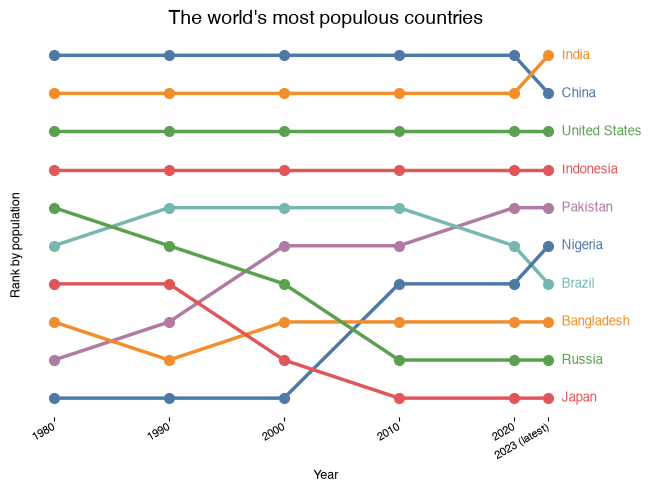

In [5]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # add the title
    title="The world's most populous countries",
    # add the x and y axis labels
    xlabel="Year",
    ylabel="Rank by population",
    # name the periods and tilt the names
    xticks=YEARS,
    xticklabels=["1980", "1990", "2000", "2010", "2020", "2023 (latest)"],
    xtickrotate=30,
).show()

### Figure size and grid

The default figure is nearly square; ten lines and their end labels read better on a full-width figure. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), sized for a full or half page width.

A bump chart draws no rank axis and no grid, since the end labels say which line is which. When the reader should count places, `show_grid` adds grid lines with a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member: `Y` draws one line per rank, `X` one per period, `BOTH` both. `aspect_ratio` fixes the ratio of the axes rather than of the figure ([ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO)); ranks and years share no unit, so the examples leave it at the default.

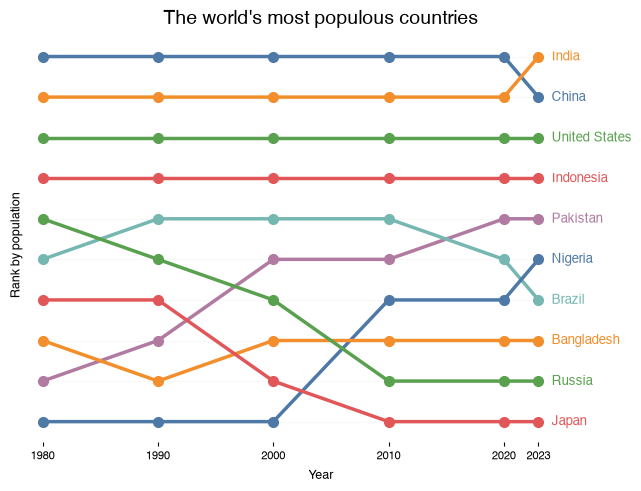

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

BumpChart(
    data=population,
    subtitle=COUNTRIES,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    # a full-width figure with room for ten lines
    figsize=FIG_SIZE.FULL_MEDIUM,
    # one grid line per rank
    show_grid=SHOW_GRID.Y,
).show()

### Ranking

A bump chart draws ranks, and `rank_by` says where they come from, with a [BUMP_RANK](../../../references/constants/#datachart.constants.BUMP_RANK) member. The choice depends on what "first" means in the data:

- `BUMP_RANK.VALUE_DESCENDING` (the default) gives rank 1 to the highest value at each period: population, revenue, points, votes. Every chart above uses it.
- `BUMP_RANK.VALUE_ASCENDING` gives rank 1 to the lowest value: race times, golf scores, prices, error rates.
- `BUMP_RANK.GIVEN` reads `y` as the rank itself, for data that already holds positions: a published league table, a music chart, a poll ranking. Each rank must be a positive whole number.

With the two value rules, ties get consecutive ranks in input order: the series listed first takes the better rank. When tied series should share a place, compute the ranks yourself and pass them with `GIVEN`, which accepts a repeated rank. A period where a series has no point is a gap: the series is left out of that period's ranking, and its line breaks there.

`stage_race`, defined in a hidden cell, is an illustrative seven-stage cycling race: each rider's total time in minutes after every stage. The leader is the rider with the *lowest* total, so the ranking is ascending. The sprinter leads after the flat opening stage, the time trialist takes over with the first time trial, and the climber wins the race in the mountains.

In [7]:
# an illustrative seven-stage race: stage times in minutes per rider
# stages: flat, time trial, flat, mountain, mountain, flat, time trial
STAGE_TIMES = {
    "Sprinter": [239.5, 31.5, 249.6, 306.0, 297.0, 244.8, 36.2],
    "Time trialist": [240.0, 29.0, 250.0, 302.5, 292.3, 245.0, 33.8],
    "Climber": [240.2, 31.3, 250.0, 297.8, 287.6, 245.1, 36.0],
    "All-rounder": [240.1, 30.0, 250.0, 299.4, 289.0, 245.0, 35.0],
    "Domestique": [240.3, 30.8, 250.3, 300.5, 291.0, 245.0, 35.4],
}
RIDERS = list(STAGE_TIMES)
stage_race = []
for times in STAGE_TIMES.values():
    total, series = 0, []
    for stage, minutes in enumerate(times, start=1):
        total += minutes
        series.append({"x": stage, "y": round(total, 1)})
    stage_race.append(series)

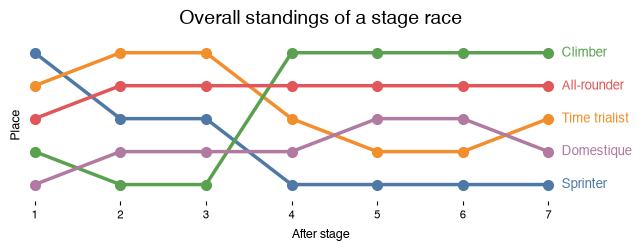

In [8]:
from datachart.constants import BUMP_RANK

BumpChart(
    data=stage_race,
    subtitle=RIDERS,
    # the lowest total time leads the race
    rank_by=BUMP_RANK.VALUE_ASCENDING,
    title="Overall standings of a stage race",
    xlabel="After stage",
    ylabel="Place",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

`premier_league`, defined in a hidden cell, holds the final Premier League positions of six clubs over nine seasons, from 2015/16 to 2023/24 (source: the official Premier League tables). Each season is named by the year it ended in, so 2016 is the 2015/16 season. The positions already are ranks, so the chart takes them with `GIVEN`, and two things follow. The ranks may skip numbers, because the other fourteen clubs of the league hold the positions in between. And Leicester City, relegated in 2023, has no point for 2023/24, so its line ends a season early.

In [9]:
# each season is named by the year it ended in: 2016 is the 2015/16 season
SEASONS = list(range(2016, 2025))

# final Premier League positions; None: the club played outside the league
POSITIONS = {
    "Man City": [4, 3, 1, 1, 2, 1, 1, 1, 1],
    "Arsenal": [2, 5, 6, 5, 8, 8, 5, 2, 2],
    "Liverpool": [8, 4, 4, 2, 1, 3, 2, 5, 3],
    "Chelsea": [10, 1, 5, 3, 4, 4, 3, 12, 6],
    "Man United": [5, 6, 2, 6, 3, 2, 6, 3, 8],
    "Leicester": [1, 12, 9, 9, 5, 5, 8, 18, None],
}
CLUBS = list(POSITIONS)
premier_league = [
    [
        {"x": season, "y": position}
        for season, position in zip(SEASONS, POSITIONS[club])
        if position is not None
    ]
    for club in CLUBS
]

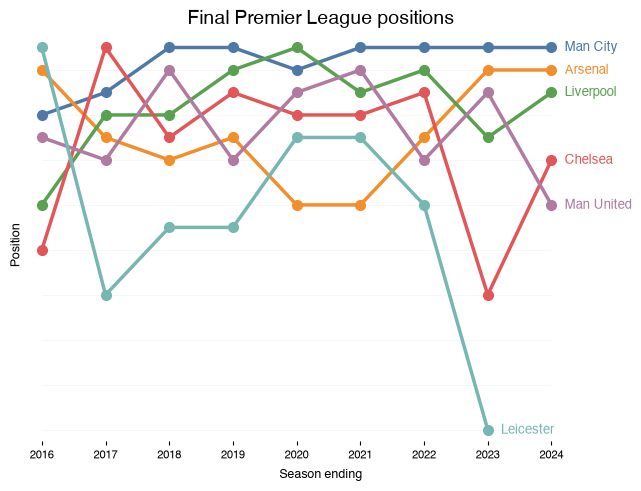

In [10]:
BumpChart(
    data=premier_league,
    subtitle=CLUBS,
    # y already holds the league position
    rank_by=BUMP_RANK.GIVEN,
    title="Final Premier League positions",
    xlabel="Season ending",
    ylabel="Position",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
).show()

### End labels

End labels replace the legend and the rank axis: the eye follows a line to its name. `show_labels` turns them on or off (on by default), and `label_position` picks the end that carries the name with a [BUMP_LABEL_POSITION](../../../references/constants/#datachart.constants.BUMP_LABEL_POSITION) member: `END` (the default), `START`, or `BOTH`. Labels at both ends show where each country started and where it finished without tracing the line across.

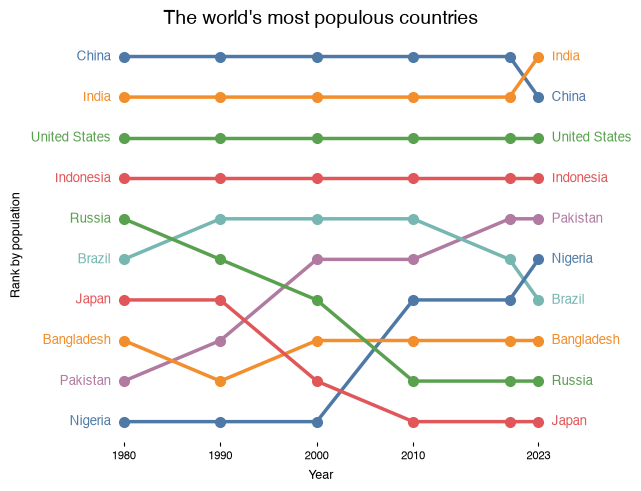

In [11]:
from datachart.constants import BUMP_LABEL_POSITION

BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # name every line at both ends
    label_position=BUMP_LABEL_POSITION.BOTH,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Line shape

Straight segments that cross at sharp angles are hard to follow when many lines swap places at once. `line_curve` eases every segment along an S-shaped curve: `0` (the default) draws straight segments, `1` a full curve, and the values in between blend the two. The curve only changes the path between two periods; every point stays on its rank. `show_markers=False` drops the markers when the lines alone read better, as in a dense table with many periods.

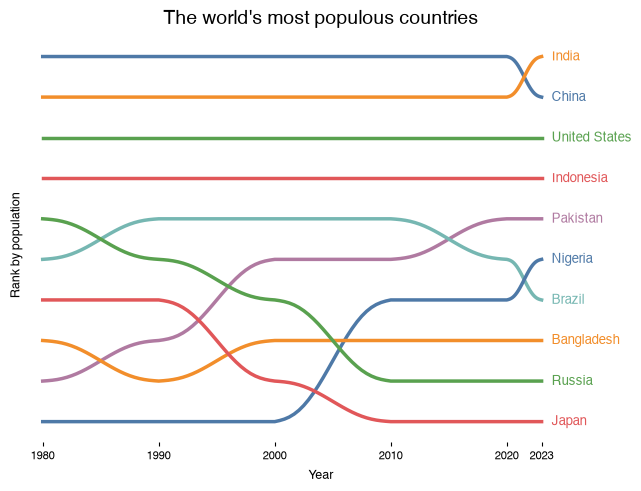

In [12]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # ease the lines between the years
    line_curve=0.8,
    # lines without the markers
    show_markers=False,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Line style

The `style` dictionary sets the look of the lines. The `plot_bump_*` attributes set what is specific to a bump chart (the line width, the marker, its size, and the gap between a line end and its label), while the color, alpha and dash come from the `plot_line_*` attributes; the attributes are listed in [datachart.typings.BumpStyleAttrs](../../../references/charts/bumpchart/#datachart.typings.BumpStyleAttrs), and the markers in [LINE_MARKER](../../../references/constants/#datachart.constants.LINE_MARKER). A single dictionary applies to every series; a list, aligned with `data`, styles each series on its own. Coloring only the two giants and drawing the rest in grey puts the story at the top of the table.

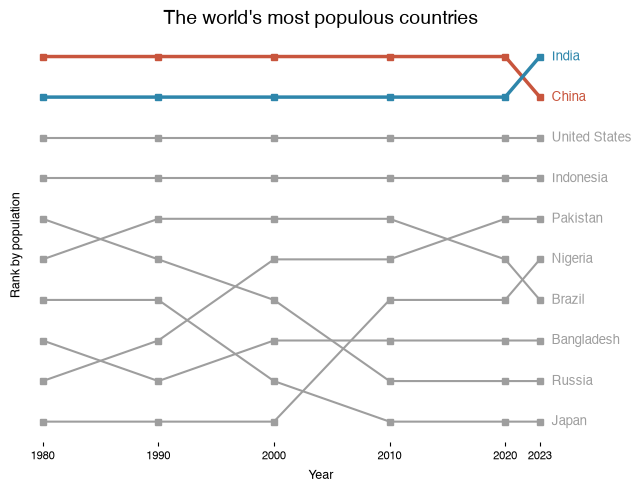

In [13]:
from datachart.constants import LINE_MARKER

GIANTS = {"China": "#c8553d", "India": "#2e86ab"}

BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # one style per series: the two giants in color, the rest in grey
    style=[
        {
            "plot_bump_line_width": 2.5 if country in GIANTS else 1.5,
            "plot_bump_marker": LINE_MARKER.SQUARE,
            "plot_bump_marker_size": 5,
            "plot_line_color": GIANTS.get(country, "#9e9e9e"),
        }
        for country in COUNTRIES
    ],
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Value labels

A rank hides the size of the gaps: rank 1 and rank 2 look the same whether they are a million or a billion apart. `show_values` prints the value behind every rank beside its marker (the original `y`, not the rank), `value_format` formats it with a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or a `"{x:.1f}"` style string, and `value_step` labels every Nth period (by default the smallest step that keeps neighbouring labels apart). Five countries keep the labels legible, and the labels show how close India and China were when they swapped places.

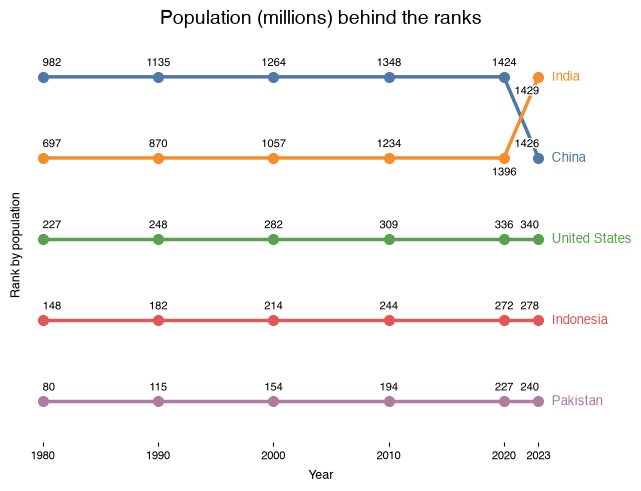

In [14]:
from datachart.constants import VALUE_FORMAT

BumpChart(
    # five countries keep the labels legible
    data=population[:5],
    subtitle=COUNTRIES[:5],
    # print the population behind every rank
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="Population (millions) behind the ranks",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Emphasis

A bump chart with ten lines usually tells the story of two or three of them. `emphasis` takes one role per series, aligned with `data`: `"highlight"` brings a line to the front, `"background"` mutes it (the theme's muted color at a lower alpha, with a muted end label), and `None` leaves it as it is. The roles are also available as the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constants, and the [Highlighting](../../styling/highlighting/) guide covers emphasis across every chart type and theme. Highlighting the two climbers and the country they passed picks one story out of ten lines.

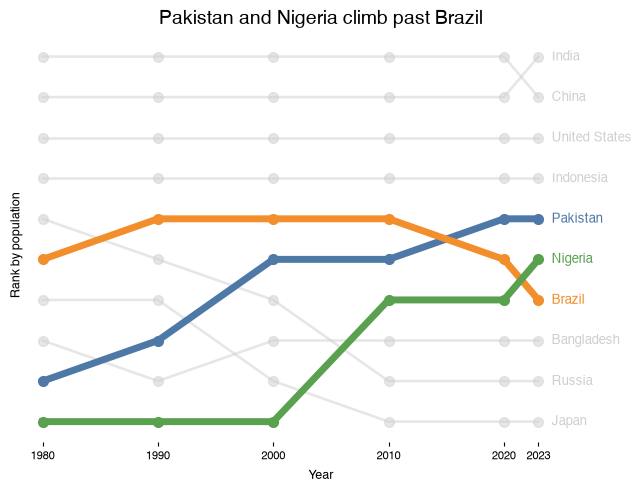

In [15]:
from datachart.constants import EMPHASIS

BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # follow the countries that climbed past Brazil
    emphasis=[
        EMPHASIS.HIGHLIGHT if country in ("Pakistan", "Nigeria", "Brazil") else EMPHASIS.BACKGROUND
        for country in COUNTRIES
    ],
    title="Pakistan and Nigeria climb past Brazil",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

`emphasis_rule` picks the lines from the data instead of naming them. On a bump chart the rule reads each series' ranks, so `{"top": n}` means the `n` best-ranked series (the lowest rank numbers) and `{"bottom": n}` the worst. The summary is the mean rank by default; a `"by"` key picks `"median"`, `"min"`, `"max"` or `"sum"` instead. The thresholds `{"above": v}`, `{"below": v}` (strict) and `{"between": (lo, hi)}` (inclusive) compare the rank number itself, so `{"below": 4}` keeps the series that ranked in the top three on average. An explicit `emphasis` role wins over the rule. In the Premier League table, `{"top": 3}` picks the three clubs with the best mean position over the nine seasons, and `"by": "median"` or `"max"` would ask about a typical or the worst season instead:

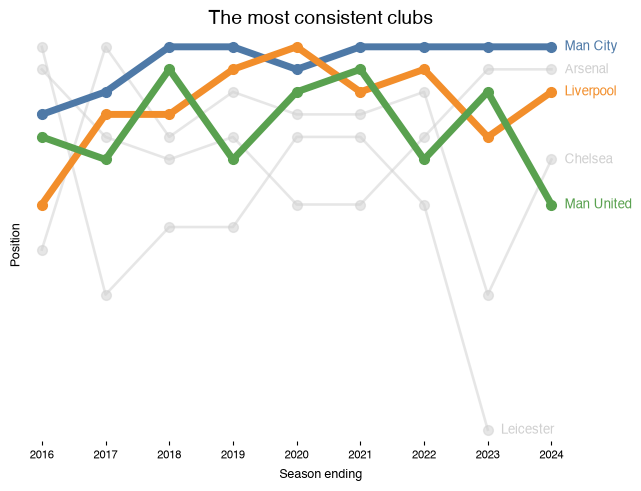

In [16]:
BumpChart(
    data=premier_league,
    subtitle=CLUBS,
    rank_by=BUMP_RANK.GIVEN,
    # the three clubs with the best mean position
    emphasis_rule={"top": 3},
    title="The most consistent clubs",
    xlabel="Season ending",
    ylabel="Position",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines and bands

Reference lines and bands give the ranks a meaning. On a bump chart their `y` is a rank: `hspans` shades a range of places, such as the qualification places of a league, and `hlines` marks a cut-off between two places (a half-rank sits between them). `vlines` and `vspans` mark periods, such as a rule change or a disrupted season. Each takes a dictionary or a list of them, with the position, a `style`, and an optional `label` that names it in the legend when `show_legend` is on; the keys are listed in [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs) and [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs). The rank axis runs from the best rank at the top (`ymin`) to the worst at the bottom (`ymax`), both defaulting to the ranks in the data; `ymax=20.5` shows all twenty places of the league, so the bands mean what they say. `xmin` and `xmax` crop the period axis the same way. The example shades the four Champions League places and the three relegation places, marks the cut-off between 17th and 18th, and shades 2019/20, the season finished behind closed doors after the pandemic pause. The season is `2020` in the data, so the band runs from `2019.5` to `2020.5`.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). On a bump chart both axes carry numbers — the season and the position — so a diagonal is a steady climb or slide through the table. The example draws one place gained per season from tenth, the pace a club would have to keep to reach the Champions League places.

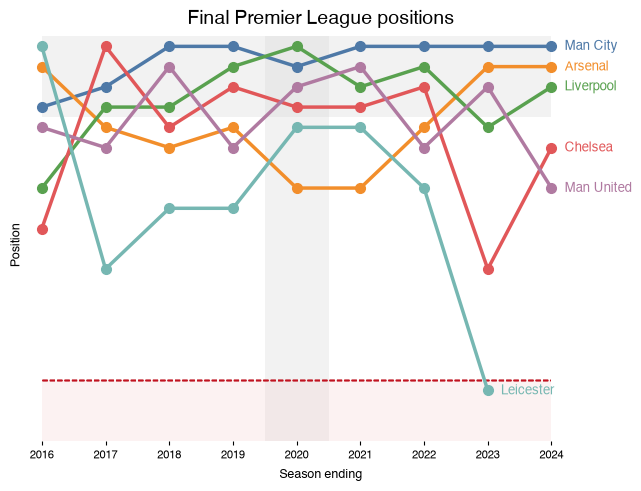

In [17]:
from datachart.constants import LINE_STYLE

BumpChart(
    data=premier_league,
    subtitle=CLUBS,
    rank_by=BUMP_RANK.GIVEN,
    # shade the Champions League and the relegation places
    hspans=[
        {"ymin": 0.5, "ymax": 4.5, "label": "Champions League"},
        {"ymin": 17.5, "ymax": 20.5, "label": "relegation", "style": {"plot_hspan_color": "#f4cccc"}},
    ],
    # the cut-off between 17th and 18th
    hlines={
        "y": 17.5,
        "style": {"plot_hline_color": "#c1121f", "plot_hline_style": LINE_STYLE.DASHED},
    },
    # the season finished after the pandemic pause
    vspans={"xmin": 2019.5, "xmax": 2020.5, "label": "pandemic season"},
    # all twenty places of the league
    ymin=0.5,
    ymax=20.5,
    title="Final Premier League positions",
    xlabel="Season ending",
    ylabel="Position",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

In [ ]:
seasons = [point["x"] for point in premier_league[0]]
FROM_SEASON, FROM_PLACE = seasons[0], 10

BumpChart(
    data=premier_league,
    subtitle=CLUBS,
    rank_by=BUMP_RANK.GIVEN,
    # one place gained per season, starting tenth: the axis counts down, so the
    # slope is negative
    dlines={
        "slope": -1,
        "intercept": FROM_PLACE + FROM_SEASON,
        "label": "one place a season",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    ymin=0.5,
    ymax=20.5,
    title="Final Premier League positions against a steady climb",
    xlabel="Season ending",
    ylabel="Position",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Text annotations

A crossing is the event a bump chart exists to show, and a note can name it. `texts` places text on the chart, with an optional `target` to draw a connector to a point; positions are in data coordinates by default (period, rank) or in axes fractions with `"coords": "axes"`, which keeps the note in place whatever the ranks. The [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. The note below sits in the free space between ranks 2 and 3, in data coordinates, and points at India's first year at the top.

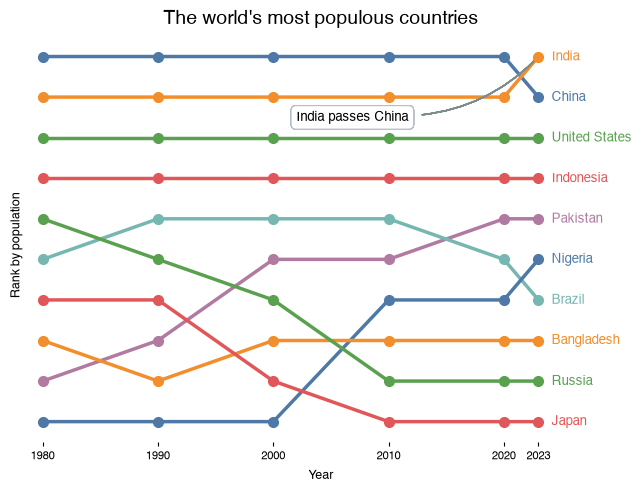

In [18]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # a note between ranks 2 and 3, pointing at India in 2023
    texts={
        "text": "India passes China",
        "x": 2002,
        "y": 2.5,
        "target": (2023, 1),
    },
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Bump Charts

A bump chart always compares series, so `data` is a list of lists: each inner list is one series, and the per-series attributes (`subtitle`, `style`, `emphasis`) are lists aligned with it. The ranks are computed across all the series of one figure. The subsections below cover the legend, subplots, and composing bump charts with other figures.

### Legend

End labels crowd when the names are long or the lines finish close together; a legend is the alternative. With `show_labels=False` the legend takes over by default, and `show_legend` sets it explicitly either way. `legend` says where and how, with a `title`, a `location` from [LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION), the number of columns `ncols`, and the `alignment` of the entries from [LEGEND_ALIGN](../../../references/constants/#datachart.constants.LEGEND_ALIGN) ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). Six club names fit to the right of the chart.

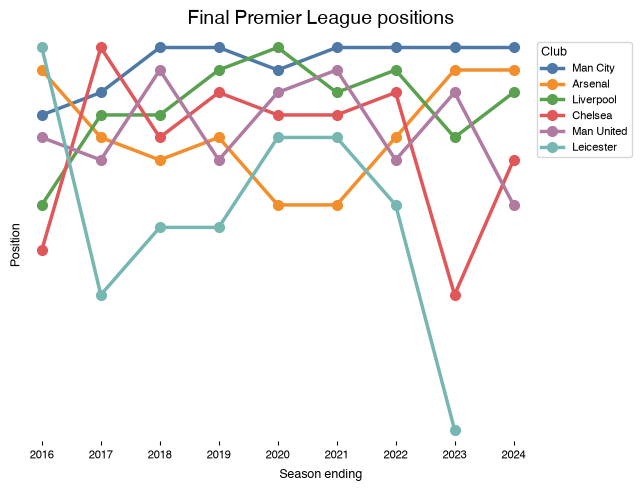

In [19]:
from datachart.constants import LEGEND_LOCATION

BumpChart(
    data=premier_league,
    subtitle=CLUBS,
    rank_by=BUMP_RANK.GIVEN,
    # a legend instead of end labels
    show_labels=False,
    legend={"title": "Club", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    title="Final Premier League positions",
    xlabel="Season ending",
    ylabel="Position",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Subplots

Ten crossing lines can hide one country's path. `subplots=True` draws each series in its own panel, and the ranks are still computed over every series, so each panel shows its country's place among all ten. `subtitle` titles the panels; `title`, `xlabel` and `ylabel` stay global; `max_cols` limits the panels per row. `sharey=True` keeps rank 1 at the same height in every panel, and `sharex=True` keeps one period axis.

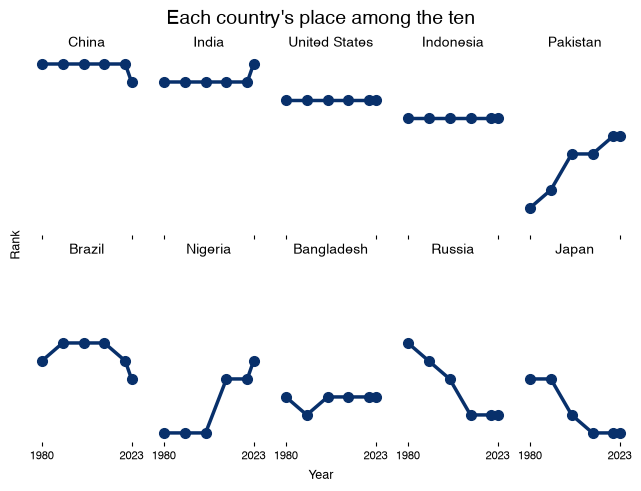

In [20]:
BumpChart(
    data=population,
    subtitle=COUNTRIES,
    # one country per panel, ranked among all ten
    subplots=True,
    max_cols=5,
    sharex=True,
    sharey=True,
    show_labels=False,
    xticks=[1980, 2023],
    title="Each country's place among the ten",
    xlabel="Year",
    ylabel="Rank",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Composing with Panel and Grid

[Panel](../../../references/utils/#datachart.utils.Panel) overlays figures built separately on one set of axes, and every bump figure keeps the ranks it computed. Two figures ranked on their own would both start at rank 1, so rankings that should share a scale are computed once and passed with `GIVEN`. The example computes the ranks of all ten countries, then draws the 2023 top five with solid lines and the rest dashed, as two figures in one panel. [Grid](../../../references/utils/#datachart.utils.Grid) arranges a bump chart next to other charts; [Example 3](#example-3-why-did-the-table-reshuffle-a-bump-chart-and-a-bar-chart-in-a-grid) stacks one above a bar chart. The [Panel](../../utility/panel/) and [Grid](../../utility/grid/) guides cover both.

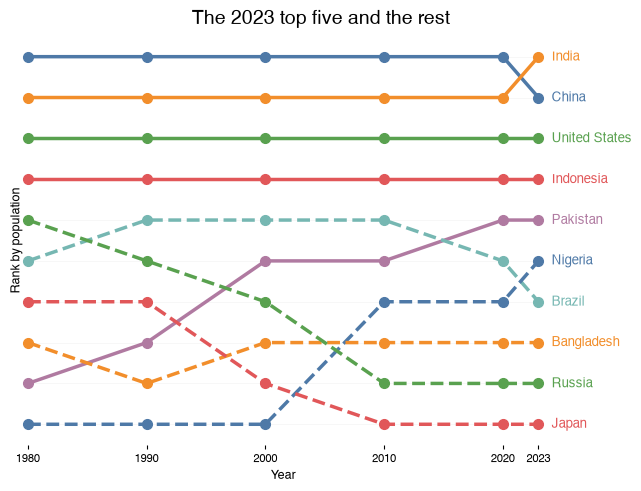

In [21]:
from datachart.utils import Panel

# the rank of every country in every year, among all ten
ranks = {country: [] for country in COUNTRIES}
for i in range(len(YEARS)):
    ordered = sorted(COUNTRIES, key=lambda country: -POPULATION[country][i])
    for rank, country in enumerate(ordered, start=1):
        ranks[country].append(rank)
top_five = [country for country in COUNTRIES if ranks[country][-1] <= 5]
the_rest = [country for country in COUNTRIES if ranks[country][-1] > 5]


def ranked(countries):
    return [[{"x": year, "y": rank} for year, rank in zip(YEARS, ranks[c])] for c in countries]


Panel(
    [
        # both figures take the shared ranks as given
        BumpChart(data=ranked(top_five), subtitle=top_five, rank_by=BUMP_RANK.GIVEN),
        BumpChart(
            data=ranked(the_rest),
            subtitle=the_rest,
            rank_by=BUMP_RANK.GIVEN,
            style={"plot_line_style": LINE_STYLE.DASHED},
        ),
    ],
    title="The 2023 top five and the rest",
    xlabel="Year",
    ylabel_left="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Additional Features

### Datetime axis

Periods are often dates, and they are not always evenly spaced: the population table has ten-year steps and then a three-year one. When `x` holds real temporal objects (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`), the axis reads as time and the points sit at their elapsed time, so the last step is drawn shorter. `xticks_format` takes a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern.

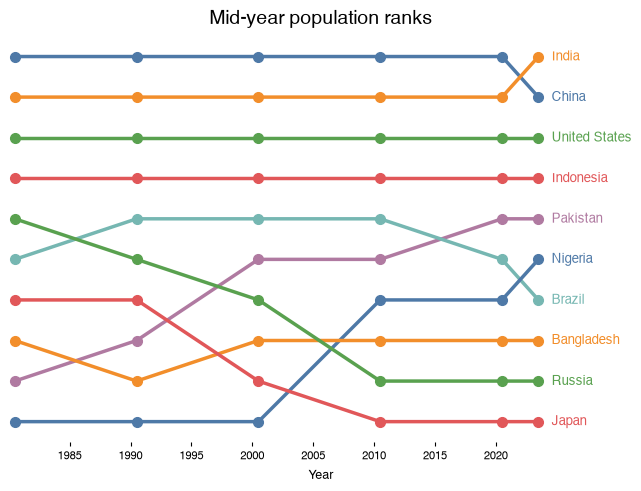

In [22]:
from datetime import date

from datachart.constants import DATE_FORMAT

BumpChart(
    # the populations dated at mid-year
    data=[
        [{"x": date(point["x"], 7, 1), "y": point["y"]} for point in series]
        for series in population
    ],
    subtitle=COUNTRIES,
    # print the dates as years
    xticks_format=DATE_FORMAT.YEAR,
    title="Mid-year population ranks",
    xlabel="Year",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Custom data keys

Data from a file or an API rarely uses the `x` and `y` keys, and renaming every record just to plot it is a chore. Instead, tell `BumpChart` which keys to read with the `x` and `y` arguments. `records` stores the population table the way a CSV export would, with a `year` and a `millions` key:

In [23]:
records = [
    [{"year": year, "millions": people} for year, people in zip(YEARS, POPULATION[country])]
    for country in COUNTRIES
]
records[0][:2]

[{'year': 1980, 'millions': 982}, {'year': 1990, 'millions': 1135}]

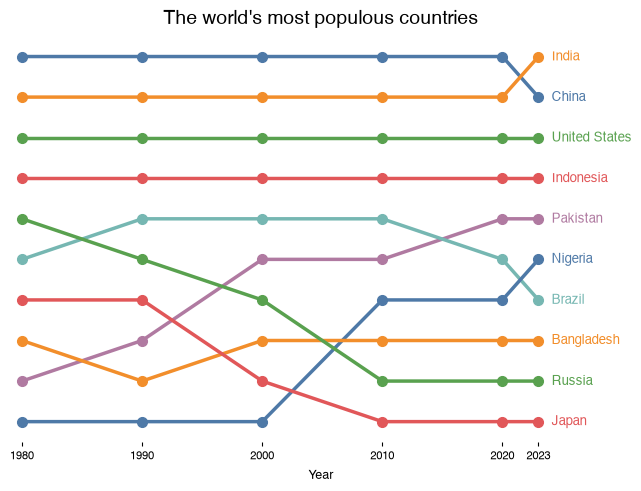

In [24]:
BumpChart(
    data=records,
    # the keys that hold the period and the value
    x="year",
    y="millions",
    subtitle=COUNTRIES,
    title="The world's most populous countries",
    xlabel="Year",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Themes

A theme sets the palette, the line width and the furniture of every chart at once; the [Theme Gallery](../../styling/theme-gallery/) shows each one. Apply one with [config.set_theme](../../../references/config/#datachart.config.Config.set_theme) and a [THEME](../../../references/constants/#datachart.constants.THEME) member, and reset the configuration afterwards so the following charts draw in the default again.

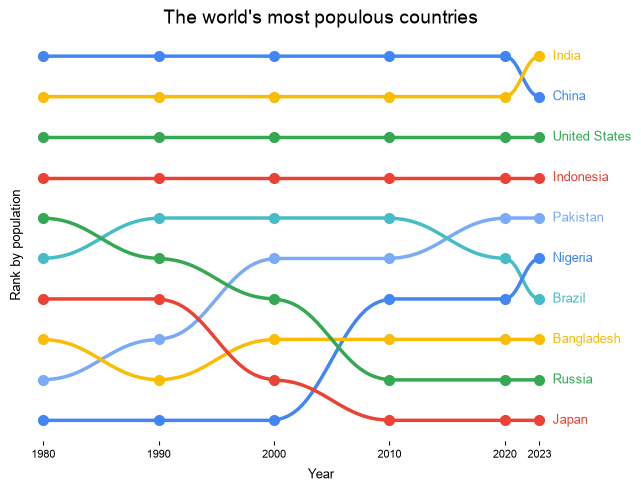

In [25]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.MATERIAL)
figure = BumpChart(
    data=population,
    subtitle=COUNTRIES,
    line_curve=0.8,
    title="The world's most populous countries",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
config.reset_config()
figure.show()

## Real-World Examples

The examples below put the features above to work on real data, each one answering a question. The data comes from the sections above; each example says what it is and where it comes from.

### Example 1: How Close Was the Swap at the Top? (Emphasis, Curves, Value Labels, and a Note)

For four decades China was the most populous country; by 2023 India had passed it. `population` (UN World Population Prospects 2022, from the Basics section) answers how narrow the crossing was. The chart keeps the four largest countries, highlights the two giants and mutes the other two, curves the lines so the one crossing stands out, prints the populations behind the ranks, and a note names the swap: 1,429 million against 1,426.

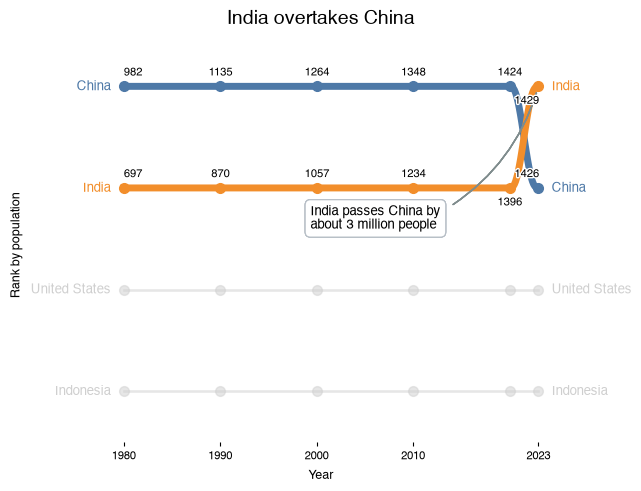

In [26]:
BumpChart(
    data=population[:4],
    subtitle=COUNTRIES[:4],
    # the two giants against the context
    emphasis=[EMPHASIS.HIGHLIGHT, EMPHASIS.HIGHLIGHT, EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND],
    line_curve=1,
    # the populations behind the ranks
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    label_position=BUMP_LABEL_POSITION.BOTH,
    texts={
        "text": "India passes China by\nabout 3 million people",
        "x": 0.45,
        "y": 0.55,
        "coords": "axes",
        "target": (2023, 1),
    },
    title="India overtakes China",
    xlabel="Year",
    ylabel="Rank by population",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Was Leicester's Title a One-Off? (Given Ranks, a Gap, Bands, and Value Labels)

In 2015/16 Leicester City won the Premier League, a title priced at 5000 to 1 before the season, ahead of all the clubs that usually share the top places. `premier_league` (the official Premier League tables, from the [Ranking](#ranking) section) holds the final positions of Leicester and five of those clubs over the following seasons. The positions are given ranks, Leicester's line breaks after its relegation in 2023, the axis shows all twenty places with bands on the Champions League places (grey) and the relegation places (red), and Leicester is highlighted with its positions printed (value labels skip muted series). The answer: Leicester never returned to the top four, though it finished fifth twice.

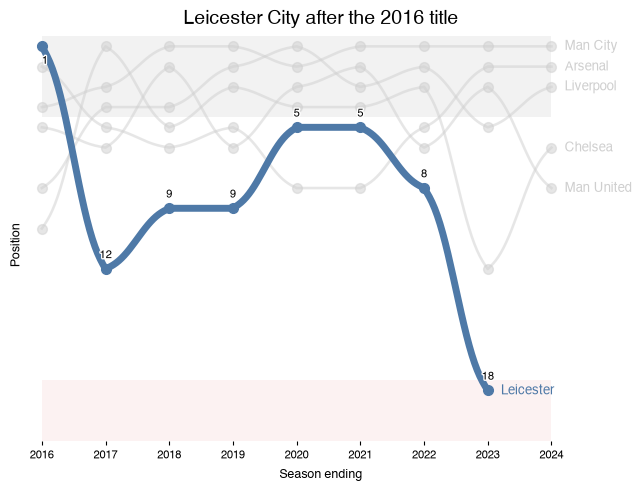

In [27]:
BumpChart(
    data=premier_league,
    subtitle=CLUBS,
    rank_by=BUMP_RANK.GIVEN,
    # Leicester against the clubs that usually finish on top
    emphasis=[EMPHASIS.BACKGROUND] * 5 + [EMPHASIS.HIGHLIGHT],
    # print Leicester's positions
    show_values=True,
    line_curve=0.5,
    # the Champions League and the relegation places
    hspans=[
        {"ymin": 0.5, "ymax": 4.5},
        {"ymin": 17.5, "ymax": 20.5, "style": {"plot_hspan_color": "#f4cccc"}},
    ],
    ymin=0.5,
    ymax=20.5,
    title="Leicester City after the 2016 title",
    xlabel="Season ending",
    ylabel="Position",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: Why Did the Table Reshuffle? (A Bump Chart and a Bar Chart in a Grid)

A bump chart shows that the order changed, not why. Between 1980 and 2023 Pakistan and Nigeria tripled their populations while Russia and Japan barely grew (`population`, UN World Population Prospects 2022, from the Basics section), and the growth explains every crossing. The top chart ranks the ten countries, highlighting the two fastest climbers and the two countries that fell furthest; the bar chart below shows each country's growth factor (the 2023 population divided by the 1980 one), sorted, with the same four countries highlighted. [Grid](../../utility/grid/) stacks the two charts in one figure.

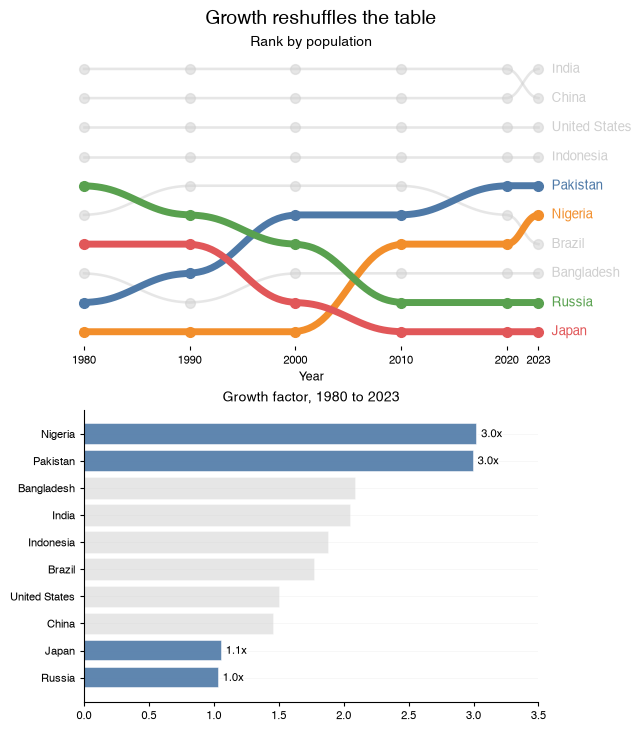

In [28]:
from datachart.charts import BarChart
from datachart.constants import ORIENTATION, SORT
from datachart.utils import Grid

MOVERS = ("Pakistan", "Nigeria", "Russia", "Japan")

ranking = BumpChart(
    data=population,
    subtitle=COUNTRIES,
    emphasis=[EMPHASIS.HIGHLIGHT if c in MOVERS else EMPHASIS.BACKGROUND for c in COUNTRIES],
    line_curve=0.8,
    title="Rank by population",
    xlabel="Year",
)
growth = BarChart(
    data=[
        {
            "label": c,
            "y": POPULATION[c][-1] / POPULATION[c][0],
            "emphasis": "highlight" if c in MOVERS else "background",
        }
        for c in COUNTRIES
    ],
    title="Growth factor, 1980 to 2023",
    orientation=ORIENTATION.HORIZONTAL,
    # the fastest growth at the top
    sort=SORT.ASCENDING,
    show_values=True,
    value_format="{:.1f}x",
    xmin=0,
    xmax=3.5,
)

Grid(
    [[ranking], [growth]],
    title="Growth reshuffles the table",
    figsize=FIG_SIZE.FULL_TALL,
).show()